In [1]:
import Labber
import numpy as np
import matplotlib.pyplot as plt
np.bool = bool
np.float = float


  Coupled System Fit Results
  Purcell Filter   : 6.70700 GHz | κ = 15.10 MHz
  Readout Resonator: 6.71594 GHz | κ = 0.60 MHz
  Coupling (J)     : 9.08 MHz


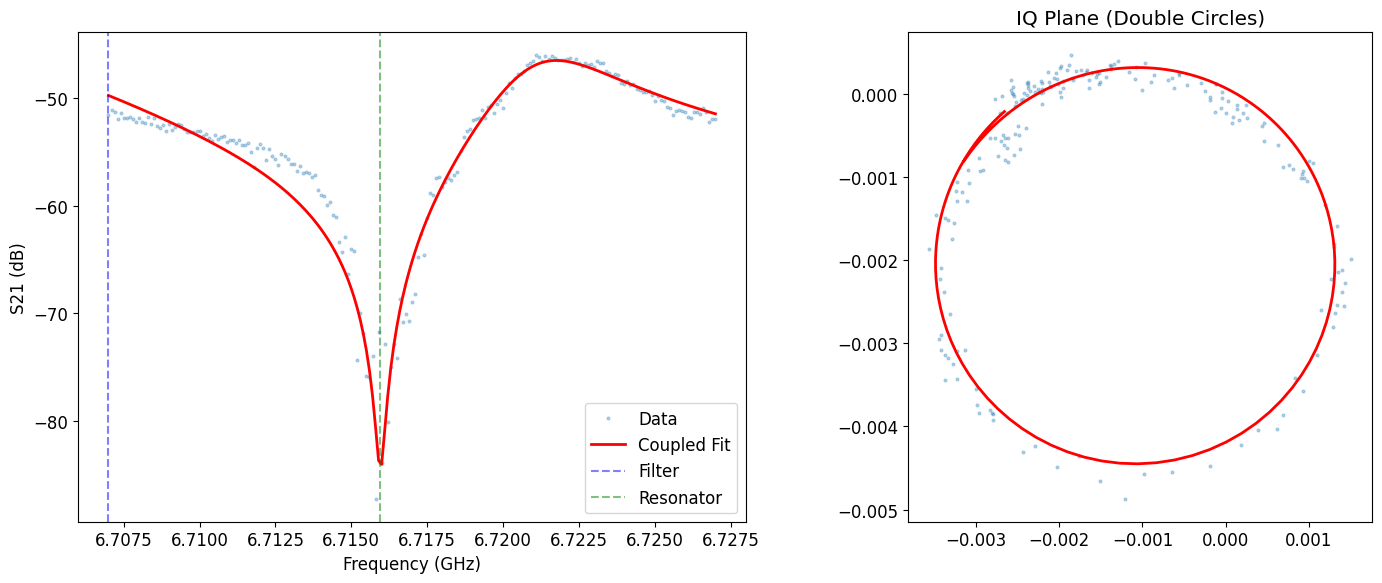

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks



def _coupled_model(freq, ff, kf, kext_f, fr, kr, J, A, phi):
    """
    雙諧振器耦合模型 (Purcell Filter + Resonator)
    ff, fr: 頻率 (GHz)
    kf, kr, J, kext_f: 頻寬與耦合項 (GHz)
    """
    delta_f = freq - ff
    delta_r = freq - fr
    
    # 這裡的算式描述了耦合系統對傳輸線的導納貢獻
    denominator = 1j * delta_f + kf/2 + (J**2) / (1j * delta_r + kr/2)
    s21 = A * np.exp(1j * phi) * (1 - (kext_f) / denominator)
    return s21

def _residuals_coupled(params, freq, s21_data):
    ff, kf, kext_f, fr, kr, J, A, phi = params
    s21_model = _coupled_model(freq, ff, kf, kext_f, fr, kr, J, A, phi)
    diff = s21_model - s21_data
    return np.concatenate([diff.real, diff.imag])



def fit_purcell_resonator_system(freq_GHz, s21_complex, plot=True):
    freq = np.asarray(freq_GHz)
    mag = np.abs(s21_complex)
    
    # --- 1. 初始值估計 ---
    # 尋找最顯著的兩個 dips
    dips, props = find_peaks(1 - mag/np.max(mag), height=0.05, prominence=0.02, distance=10)
    
    if len(dips) >= 2:
        sorted_dips = dips[np.argsort(props['prominences'])[::-1][:2]]
        f_peaks = np.sort(freq[sorted_dips])
        ff_init, fr_init = f_peaks[1], f_peaks[0] # 假設較高頻的是 Filter (通常設計如此)
    else:
        # 如果沒抓到兩個，就用單點附近猜
        ff_init = freq[np.argmin(mag)]
        fr_init = ff_init - 0.050 # 猜相差 50 MHz
    
    # 寬度與耦合的初始猜測
    kf_init = 0.020 
    kr_init = 0.002
    J_init  = 0.010
    kext_init = kf_init * 0.8
    A_init = np.max(mag)
    
    # [ff, kf, kext_f, fr, kr, J, A, phi]
    p0 = [ff_init, kf_init, kext_init, fr_init, kr_init, J_init, A_init, 0.0]
    
    # 設定合理邊界
    bounds = (
        [freq[0], 1e-5, 1e-6, freq[0], 1e-6, 1e-6, 0, -np.pi],
        [freq[-1], 0.2, 0.2, freq[-1], 0.05, 0.1, 2.0, np.pi]
    )

    # --- 2. 執行擬合 ---
    res = least_squares(_residuals_coupled, p0, bounds=bounds, args=(freq, s21_complex), ftol=1e-12)
    ff, kf, kext_f, fr, kr, J, A, phi = res.x
    
    s21_fit = _coupled_model(freq, *res.x)
    
    # --- 3. 整理結果 ---
    results = {
        'filter_f0_GHz': ff,
        'filter_kappa_MHz': kf * 1e3,
        'filter_kext_MHz': kext_f * 1e3,
        'resonator_f0_GHz': fr,
        'resonator_kappa_MHz': kr * 1e3,
        'coupling_J_MHz': J * 1e3,
        'Q_res': fr / kr
    }

    # --- 4. 輸出與繪圖 ---
    print(f"\n{'='*50}\n  Coupled System Fit Results\n{'='*50}")
    print(f"  Purcell Filter   : {ff:.5f} GHz | κ = {kf*1e3:.2f} MHz")
    print(f"  Readout Resonator: {fr:.5f} GHz | κ = {kr*1e3:.2f} MHz")
    print(f"  Coupling (J)     : {J*1e3:.2f} MHz")
    print(f"{'='*50}")

    if plot:
        _plot_coupled_results(freq, s21_complex, s21_fit, results)
        
    return results

def _plot_coupled_results(freq, data, fit, res):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Mag Plot
    axes[0].plot(freq, 20*np.log10(np.abs(data)), 'o', ms=2, alpha=0.3, label='Data')
    axes[0].plot(freq, 20*np.log10(np.abs(fit)), '-', lw=2, color='red', label='Coupled Fit')
    axes[0].axvline(res['filter_f0_GHz'], color='blue', ls='--', alpha=0.5, label='Filter')
    axes[0].axvline(res['resonator_f0_GHz'], color='green', ls='--', alpha=0.5, label='Resonator')
    axes[0].set_ylabel('S21 (dB)')
    axes[0].set_xlabel('Frequency (GHz)')
    axes[0].legend()
    
    # IQ Plot
    axes[1].plot(data.real, data.imag, 'o', ms=2, alpha=0.3)
    axes[1].plot(fit.real, fit.imag, '-', lw=2, color='red')
    axes[1].set_aspect('equal')
    axes[1].set_title('IQ Plane (Double Circles)')
    
    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════
#  使用範例
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":
    file = r'D:\Labber_Data\Jay\purcell_tmon\2026\01\Data_0112\R1.hdf5'
    data = Labber.LogFile(file)
    freq, S21 = data.getTraceXY(entry=-1)
    fit_results = fit_purcell_resonator_system(freq/1e9, S21)


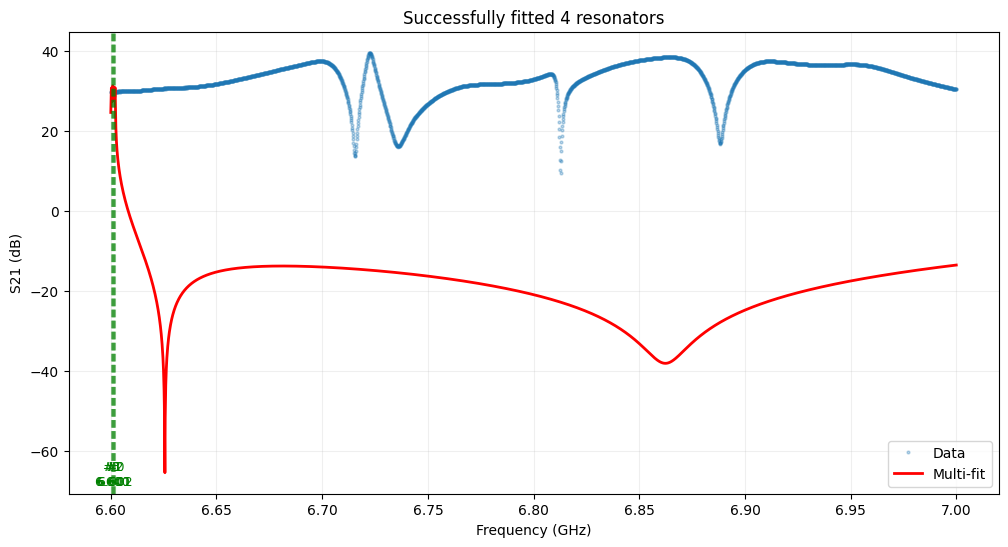

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import find_peaks

# ══════════════════════════════════════════════════════════════
#  1 多模態複數模型
# ══════════════════════════════════════════════════════════════

def n_resonator_model(freq, p, num_res):
    """
    p 結構: [A, slope, tau, phi_bg,  (f0, kt, ke, phi_res) * num_res]
    """
    A, slope, tau, phi_bg = p[0:4]
    omega = 2 * np.pi * freq
    
    # 背景項 (包含振幅斜率與線性相位延遲)
    background = (A + slope * (freq - np.mean(freq))) * np.exp(1j * (omega * tau + phi_bg))
    
    # 諧振項累加
    res_sum = 0
    for i in range(num_res):
        idx = 4 + i * 4
        f0, kt, ke, phi_res = p[idx : idx + 4]
        res_sum += (ke * np.exp(1j * phi_res) / 2) / (1j * (freq - f0) + kt / 2)
        
    return background * (1 - res_sum)

def _residuals_multi(params, freq, s21_data, num_res):
    s21_model = n_resonator_model(freq, params, num_res)
    diff = s21_model - s21_data
    return np.concatenate([diff.real, diff.imag])

# ══════════════════════════════════════════════════════════════
#  2 主擬合器
# ══════════════════════════════════════════════════════════════

def fit_all_resonators(freq_GHz, s21_complex, num_res=3, plot=True):
    freq = np.asarray(freq_GHz)
    mag = np.abs(s21_complex)
    
    # --- 1. 自動尋找初始值 ---
    # 找最顯著的 num_res 個 dips
    dips, props = find_peaks(1 - mag/np.max(mag), prominence=0.02, distance=20)
    if len(dips) < num_res:
        print(f"警告：自動偵測僅找到 {len(dips)} 個峰值，將使用其餘位置的最小點。")
        sorted_indices = np.argsort(mag)[:num_res]
    else:
        # 取最有影響力的前 N 個
        sorted_indices = dips[np.argsort(props['prominences'])[::-1][:num_res]]
    
    f_guesses = np.sort(freq[sorted_indices])
    
    # 背景參數 [A, slope, tau, phi_bg]
    p0 = [np.mean(mag), 0, 0, 0]
    
    # 每個諧振器的參數 [f0, kt, ke, phi_res]
    for fg in f_guesses:
        p0 += [fg, 0.005, 0.004, 0.0] # 預設頻寬 5 MHz
    
    # --- 2. 執行 Least Squares ---
    res = least_squares(_residuals_multi, p0, args=(freq, s21_complex, num_res), ftol=1e-12)
    final_p = res.x
    s21_fit = n_resonator_model(freq, final_p, num_res)
    
    # --- 3. 整理結果 ---
    extracted_params = []
    for i in range(num_res):
        idx = 4 + i * 4
        extracted_params.append({
            'f0_GHz': final_p[idx],
            'kappa_total_MHz': abs(final_p[idx+1]) * 1e3,
            'kappa_ext_MHz': abs(final_p[idx+2]) * 1e3,
            'Q_total': final_p[idx] / abs(final_p[idx+1])
        })
    
    if plot:
        _plot_multi_results(freq, s21_complex, s21_fit, extracted_params)
        
    return extracted_params

def _plot_multi_results(freq, data, fit, params):
    plt.figure(figsize=(12, 6))
    plt.plot(freq, 20*np.log10(np.abs(data)), 'o', ms=2, alpha=0.3, label='Data')
    plt.plot(freq, 20*np.log10(np.abs(fit)), '-', lw=2, color='red', label='Multi-fit')
    
    for i, p in enumerate(params):
        plt.axvline(p['f0_GHz'], color='green', ls='--', alpha=0.5)
        plt.text(p['f0_GHz'], plt.gca().get_ylim()[0]+2, f"#{i}\n{p['f0_GHz']:.3f}", 
                 ha='center', fontsize=9, color='green')
        
    plt.title(f"Successfully fitted {len(params)} resonators")
    plt.ylabel('S21 (dB)')
    plt.xlabel('Frequency (GHz)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# ══════════════════════════════════════════════════════════════
#  範例用法
file = r'D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0331\s002_onetone_ge_Q2_002.hdf5'
data = Labber.LogFile(file)
freq, S21 = data.getTraceXY(entry=-1)
res_list = fit_all_resonators(freq/1e9, S21, num_res=4)


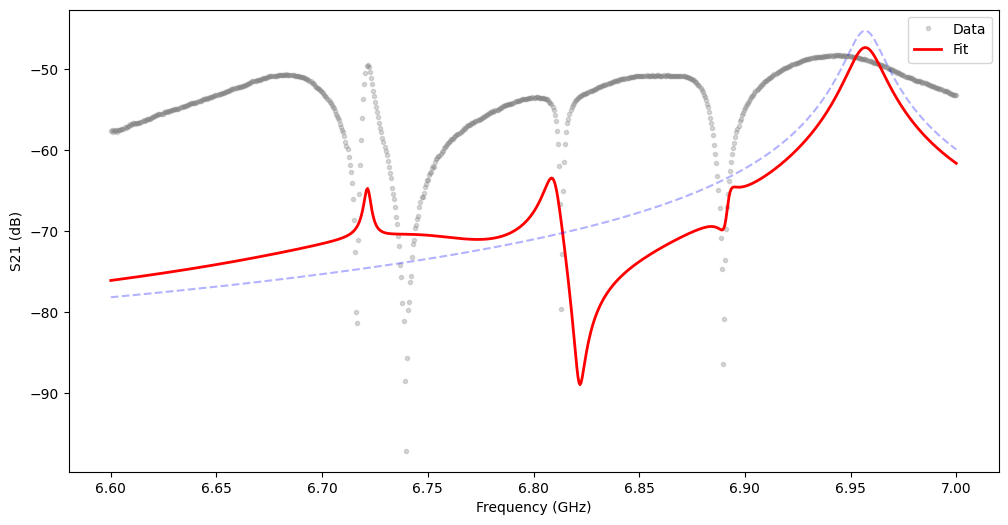


═══════════════════════════════════════════════════════════════════════════
ID   | Preset (GHz) | Fit f0 (GHz) | kappa (MHz) | Q_total    | Err (MHz)
───────────────────────────────────────────────────────────────────────────
0    | 6.7170       | 6.72148      | 3.50       | 1920.8     | +4.48   
1    | 6.7400       | 6.75000      | 100.00     | 67.5       | +10.00  
2    | 6.8100       | 6.80971      | 7.82       | 871.2      | -0.29   
3    | 6.8900       | 6.89208      | 4.63       | 1487.3     | +2.08   
═══════════════════════════════════════════════════════════════════════════

Purcell Filter Background Info:
  > Center Frequency (ff): 6.9569 GHz
  > Bandwidth (kf)       : 16.28 MHz
  > Electrical Delay(tau): -5.1961 ns


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ══════════════════════════════════════════════════════════════
#  1 模型定義
# ══════════════════════════════════════════════════════════════

def purcell_bg_model(freq, p):
    ff, kf, Af = p
    return Af / np.sqrt(1 + (2 * (freq - ff) / kf)**2)

def full_complex_model(freq, p, num_res):
    ff, kf, Af, tau, phi_bg = p[0:5]
    mag_bg = purcell_bg_model(freq, [ff, kf, Af])
    omega = 2 * np.pi * freq
    background = mag_bg * np.exp(1j * (omega * tau + phi_bg))
    
    res_sum = 0
    for i in range(num_res):
        idx = 5 + i * 4
        f0, kt, ke, phi_res = p[idx : idx + 4]
        res_sum += (ke * np.exp(1j * phi_res) / 2) / (1j * (freq - f0) + kt / 2)
    return background * (1 - res_sum)

# ══════════════════════════════════════════════════════════════
#  2 強健型擬合器
# ══════════════════════════════════════════════════════════════
def robust_multi_fit(freq_raw, s21_raw, f_presets, plot=True):
    freq = np.asarray(freq_raw).flatten()
    s21 = np.asarray(s21_raw).flatten()
    
    # 1. 單位檢查：如果已經除過 1e9，平均值會很小
    if np.nanmean(freq) > 1e6:
        freq = freq / 1e9
    
    num_res = len(f_presets)

    # 步驟 1: 背景振幅初步擬合
    mag_data = np.abs(s21)
    def bg_res(p): return purcell_bg_model(freq, p) - mag_data
    
    idx_max = np.nanargmax(mag_data)
    p_bg_init = [freq[idx_max], 0.2, np.max(mag_data)]
    res_bg = least_squares(bg_res, p_bg_init, bounds=([np.min(freq), 0.01, 0], [np.max(freq), 1.0, np.inf]))
    ff_est, kf_est, Af_est = res_bg.x

    # 步驟 2: 相位延遲初步估計
    phase = np.unwrap(np.angle(s21))
    slope, intercept = np.polyfit(2 * np.pi * freq, phase, 1)
    tau_est = slope
    # --- 關鍵修正：將相位截距摺疊回 +/- pi 之間 ---
    phi_est = (intercept + np.pi) % (2 * np.pi) - np.pi

    # 步驟 3: 全系統擬合邊界設定
    p0 = [ff_est, kf_est, Af_est, tau_est, phi_est]
    # 確保 lb 永遠小於 ub
    f_min, f_max = np.min(freq), np.max(freq)
    lb = [f_min, 0.001, Af_est*0.1, -np.inf, -2*np.pi]
    ub = [f_max, 2.0, Af_est*10.0, np.inf, 2*np.pi]

    for f_p in f_presets:
        p0 += [f_p, 0.001, 0.0008, 0.0]
        lb += [f_p - 0.01, 1e-7, 1e-8, -np.pi]
        ub += [f_p + 0.01, 0.1, 0.1, np.pi]

    # --- 關鍵修正：強制裁切 p0 確保他在邊界內 ---
    p0 = np.clip(p0, lb, ub)

    def full_res(p):
        diff = full_complex_model(freq, p, num_res) - s21
        weight = 1.0 / (np.abs(s21) + 0.1 * Af_est)
        return np.concatenate([diff.real * weight, diff.imag * weight])

    # 執行最終擬合
    res_final = least_squares(full_res, p0, bounds=(lb, ub), ftol=1e-13)
    final_p = res_final.x
    s21_fit = full_complex_model(freq, final_p, num_res)

    # 整理結果
    extracted = []
    for i in range(num_res):
        idx = 5 + i * 4
        extracted.append({'f0_GHz': final_p[idx], 'kappa_MHz': final_p[idx+1]*1e3})

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(freq, 20*np.log10(np.abs(s21)), '.', color='gray', alpha=0.3, label='Data')
        plt.plot(freq, 20*np.log10(np.abs(s21_fit)), '-', color='red', lw=2, label='Fit')
        plt.plot(freq, 20*np.log10(purcell_bg_model(freq, final_p[0:3])), '--', color='blue', alpha=0.3)
        plt.ylabel('S21 (dB)')
        plt.xlabel('Frequency (GHz)')
        plt.legend()
        plt.show()

    return extracted, final_p[0:5]

# ══════════════════════════════════════════════════════════════
#  3 資訊印出
# ══════════════════════════════════════════════════════════════

def print_fit_report(extracted_results, f_presets):
    print(f"\n{'═'*75}")
    print(f"{'ID':<4} | {'Preset (GHz)':<12} | {'Fit f0 (GHz)':<12} | {'kappa (MHz)':<10} | {'Q_total':<10} | {'Err (MHz)':<8}")
    print(f"{'─'*75}")
    for i, res in enumerate(extracted_results):
        f0 = res['f0_GHz']
        kappa = res['kappa_MHz']
        q_total = (f0 * 1e3) / kappa 
        error_mhz = (f0 - f_presets[i]) * 1e3
        print(f"{i:<4} | {f_presets[i]:<12.4f} | {f0:<12.5f} | {kappa:<10.2f} | {q_total:<10.1f} | {error_mhz:<+8.2f}")
    print(f"{'═'*75}\n")

# ══════════════════════════════════════════════════════════════
#  執行範例
# ══════════════════════════════════════════════════════════════

file = r'D:\Labber_Data\Jay\purcell_tmon\2026\01\Data_0114\Rpurcell.hdf5'
# file = r'D:\Labber_Data\Jay\purcell_tmon\2026\01\Data_0112\broad band pdr_2.hdf5'
data = Labber.LogFile(file)
freq, S21 = data.getTraceXY(entry=0)
my_presets = [6.717, 6.74, 6.81, 6.89] 
results, filter_params = robust_multi_fit(freq/1e9, S21, f_presets=my_presets)

if results:
    print_fit_report(results, my_presets)
    
    # 印出 Purcell Filter 背景資訊
    ff, kf, Af, tau, phi_bg = filter_params
    print(f"Purcell Filter Background Info:")
    print(f"  > Center Frequency (ff): {ff:.4f} GHz")
    print(f"  > Bandwidth (kf)       : {kf*1e3:.2f} MHz")
    print(f"  > Electrical Delay(tau): {tau:.4f} ns")

